<a href="https://colab.research.google.com/github/Saptomita/Lab_work/blob/main/Lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install networkx matplotlib

Problem 3: Checking Routes Between Cities Using DFS
Problem Statement:
A small road network connects several cities. Write a Python program using DFS that:
1. Checks whether a route exists between two given cities.
2. Finds all separate groups of cities that are connected to each other but not to any
other group (these are called connected components).


Enter number of cities: 8
Enter city name: Pune
Enter city name: Mumbai
Enter city name: Bankura
Enter city name: Durgapur
Enter city name: Kolkata
Enter city name: Asansol
Enter city name: Ranchi
Enter city name: Dhanbad
Enter number of roads: 7
Enter connected cities: Pune Mumbai
Enter connected cities:  Bankura Durgapur
Enter connected cities: Durgapur Kolkata
Enter connected cities: Kolkata Asansol
Enter connected cities: Asansol Ranchi
Enter connected cities: Asansol Dhanbad
Enter connected cities: Ranchi Dhanbad

Enter source and destination: Bankura Ranchi

Route exists between Bankura and Ranchi

Connected Components:
Component 1 : Mumbai, Pune
Component 2 : Bankura, Ranchi, Kolkata, Durgapur, Dhanbad, Asansol


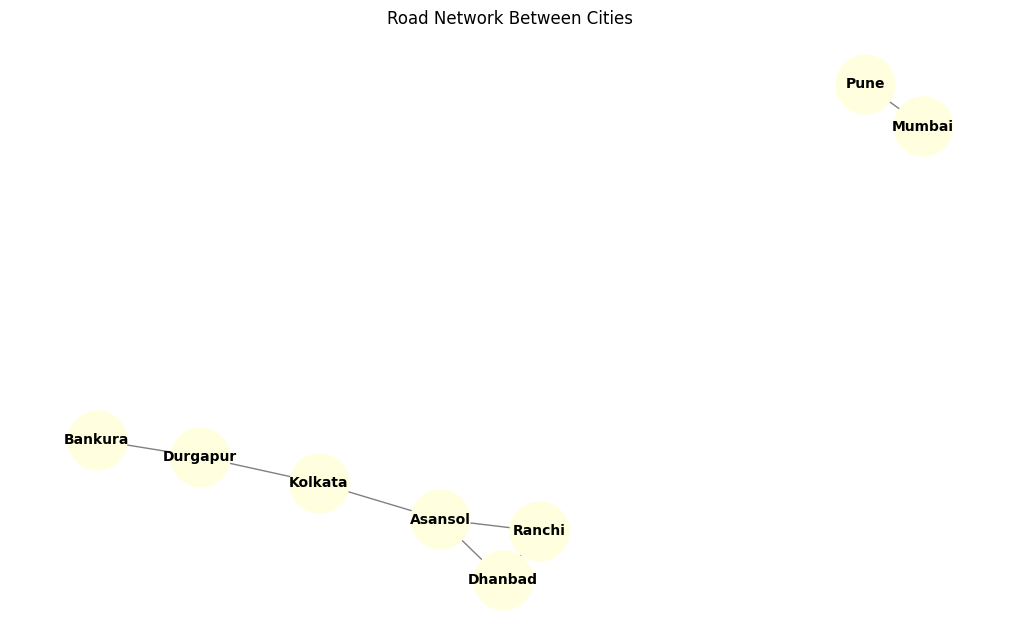

In [11]:
import networkx as nx
import matplotlib.pyplot as plt


# DFS function
def dfs(graph, city, visited):
    visited.add(city)

    for neighbour in graph[city]:
        if neighbour not in visited:
            dfs(graph, neighbour, visited)


# User input
n = int(input("Enter number of cities: "))

graph = {}

for i in range(n):
    city = input("Enter city name: ")
    graph[city] = []


# Number of roads
r = int(input("Enter number of roads: "))

for i in range(r):
    a, b = input("Enter connected cities: ").split()
    graph[a].append(b)
    graph[b].append(a)


# Check route
start, end = input("\nEnter source and destination: ").split()

visited = set()
dfs(graph, start, visited)

if end in visited:
    print("\nRoute exists between", start, "and", end)
else:
    print("\nNo route exists between", start, "and", end)


# Find connected components
visited = set()
components = []

for city in graph:
    if city not in visited:
        component = set()
        dfs(graph, city, component)
        visited.update(component)
        components.append(component)


print("\nConnected Components:")

for i, component in enumerate(components, 1):
    print("Component", i, ":", ", ".join(component))


# Create graph for map
G = nx.Graph()

for city in graph:
    for neighbour in graph[city]:
        G.add_edge(city, neighbour)


# Automatically arrange the cities
pos = nx.spring_layout(G, seed=42)


# Display map
plt.figure(figsize=(10, 6))

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=1800,
    node_color="lightyellow",
    edge_color="gray",
    font_size=10,
    font_weight="bold"
)

plt.title("Road Network Between Cities")
plt.axis("off")
plt.show()